# 4. Fixed-pattern correction

Channels 2, 3, 5 and 6 (and to a lesser extent 1) show a fixed spatial pattern that remains in the final data. Its amplitude depends on the scene temperature and is largest for cold scenes. `velox_tools.correction` estimates the pattern empirically and removes it:

1. `poly_detrend` removes a 2nd-order polynomial surface from every frame, which strips the large-scale structure of the scene itself.
2. `build_correction_table` sorts many frames into bins of scene temperature (`BT_Center`) and takes the per-pixel median of the residuals in every bin.
3. `apply_correction` subtracts the pattern, interpolated to the scene temperature of each frame.

A table built from HALO-(AC)3 clear-sky frames over sea ice ships with the package.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap

import velox_tools
from velox_tools import campaign
from velox_tools.correction import apply_correction, build_correction_table, poly_detrend

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=['#2a78d6', '#eb6834']),
})
diverging = LinearSegmentedColormap.from_list('diverging', ['#104281', '#f0efec', '#b3261e'])

## The shipped correction table

The table's `band` dimension is the position of the channel: bands 0-4 are channels 1, 2, 3, 5 and 6. `n_frames` is the number of frames per temperature bin.

In [2]:
table = xr.open_dataset(os.path.join(os.path.dirname(velox_tools.__file__), 'data', 'correction_table_v1.nc'))
table

<xarray.Dataset> Size: 45MB
Dimensions:   (band: 5, Tbin: 7, x: 635, y: 507)
Coordinates:
  * band      (band) int64 40B 0 1 2 3 4
  * Tbin      (Tbin) float64 56B -37.5 -32.5 -27.5 -22.5 -17.5 -12.5 -7.5
  * x         (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y         (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    pattern   (band, Tbin, x, y) float32 45MB ...
    n_frames  (band, Tbin) float64 280B ...
Attributes:
    method:              poly_detrend+robust_median
    order:               2
    bin_width:           5.0
    min_frames_per_bin:  30
    max_frames_per_bin:  800
    description:         VELOX fixed-pattern correction table -- see velox_to...

In [3]:
table['n_frames'].assign_coords(band=campaign.CHANNELS).rename(band='channel').to_pandas().astype('Int64')

Tbin,-37.5,-32.5,-27.5,-22.5,-17.5,-12.5,-7.5
channel,,,,,,,
1,<NA>,800,800,800,800,726,207
2,800,800,800,800,800,636,182
3,800,800,800,800,800,595,248
5,765,800,800,800,800,628,181
6,152,800,800,800,800,730,230


The pattern of channel 3 in three temperature bins (subtracted from the data):

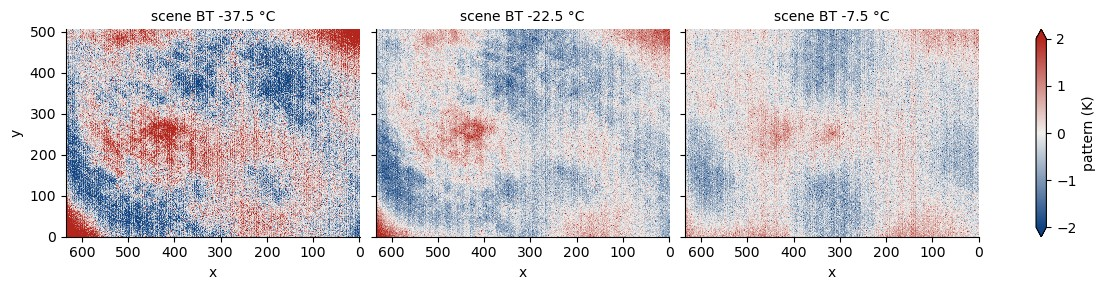

In [4]:
pattern = table['pattern'].sel(band=2, Tbin=[-37.5, -22.5, -7.5])
lim = float(abs(pattern).quantile(0.98))
g = pattern.plot.imshow(x='x', y='y', col='Tbin', cmap=diverging, vmin=-lim, vmax=lim,
                        size=3, aspect=635 / 507, cbar_kwargs=dict(label='pattern (K)'))
g.set_titles('scene BT {value} °C')
for ax in g.axs.flat:
    ax.invert_xaxis()

## A homogeneous scene

One minute of channel 3 over sea ice during HALO-(AC)3 (RF13). The scene is almost uniform, so the fixed pattern stands out.

In [5]:
scene = campaign.load_velox(slice('2022-04-04T10:20:00', '2022-04-04T10:20:59'), channels=3).sel(band=3).load()
bt, scene_bt = scene['BT_2D'], scene['BT_Center']
print(f'{bt.sizes["time"]} frames, BT_Center {float(scene_bt.min()):.1f} to {float(scene_bt.max()):.1f} °C')
print(f'table covers {float(table.Tbin.min()) - 2.5:.0f} to {float(table.Tbin.max()) + 2.5:.0f} °C')

59 frames, BT_Center -40.8 to -35.5 °C
table covers -40 to -5 °C


## Applying the correction

`apply_correction` needs the brightness temperatures of one channel, its scene temperature and the band of the table:

In [6]:
corrected = apply_correction(bt, scene_bt, table, band=2)

The pattern is hard to see in a single frame. `poly_detrend` removes the large-scale structure of every frame; averaged over the minute, the moving scene blurs out and the fixed pattern remains -- before, but not after the correction:

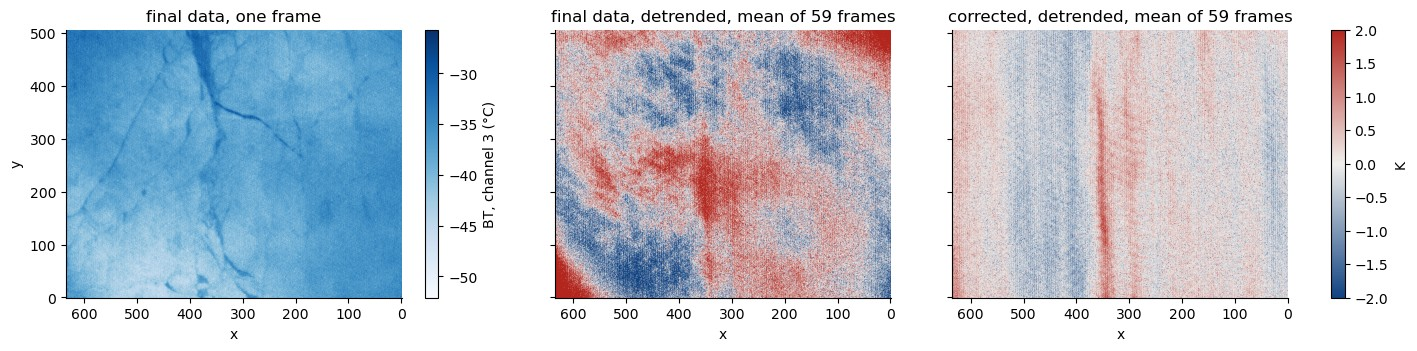

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True, layout='constrained')
m = axes[0].imshow(bt.isel(time=0).T, origin='lower', cmap='Blues')
fig.colorbar(m, ax=axes[0], label='BT, channel 3 (°C)')
axes[0].set_title('final data, one frame')
for ax, data, title in zip(axes[1:], [bt, corrected], ['final data', 'corrected']):
    m = ax.imshow(poly_detrend(data.values).mean(axis=0).T, origin='lower', cmap=diverging, vmin=-lim, vmax=lim)
    ax.set_title(f'{title}, detrended, mean of {bt.sizes["time"]} frames')
fig.colorbar(m, ax=axes[1:], label='K')
for ax in axes:
    ax.invert_xaxis()
    ax.set_xlabel('x')
axes[0].set_ylabel('y');

The spatial standard deviation of every frame drops:

mean spatial std: 2.632 K -> 2.390 K (9 % lower)


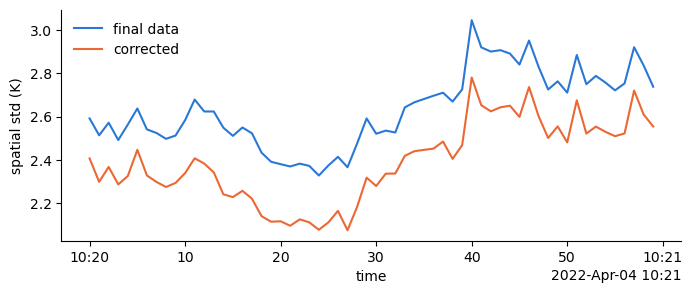

In [8]:
before = bt.std(['x', 'y'])
after = corrected.std(['x', 'y'])
print(f'mean spatial std: {float(before.mean()):.3f} K -> {float(after.mean()):.3f} K '
      f'({100 * (1 - float(after.mean()) / float(before.mean())):.0f} % lower)')

fig, ax = plt.subplots(figsize=(8, 3))
before.plot(ax=ax, label='final data', linewidth=1.5)
after.plot(ax=ax, label='corrected', linewidth=1.5)
ax.set(ylabel='spatial std (K)', title='')
ax.legend(frameon=False);

Outside the temperature range of the table, the pattern is extrapolated from the outermost bins. Check `Tbin` before applying it to warmer or colder scenes -- the shipped table does not cover tropical scenes, for example.

## Building your own table

`build_correction_table` needs `BT_2D` `(band, time, x, y)` and `BT_Center` `(band, time)`. A reliable table needs a large, varied pool of frames (the shipped one used up to 800 per bin, from many flights): with too few scenes, the median keeps real scene structure. The minute from above only demonstrates the call:

In [9]:
pool = scene.expand_dims('band')
own = build_correction_table(pool, bin_width=5.0, min_frames_per_bin=20)
own

<xarray.Dataset> Size: 1MB
Dimensions:   (band: 1, Tbin: 1, x: 635, y: 507)
Coordinates:
  * band      (band) int64 8B 0
  * Tbin      (Tbin) float64 8B -37.5
  * x         (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y         (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    pattern   (band, Tbin, x, y) float32 1MB -2.422 -1.833 ... 0.7051 0.5698
    n_frames  (band, Tbin) float64 8B 55.0
Attributes:
    method:              poly_detrend+robust_median
    order:               2
    bin_width:           5.0
    min_frames_per_bin:  20
    max_frames_per_bin:  -1
    description:         VELOX fixed-pattern correction table -- see velox_to...

In [10]:
a = own['pattern'].isel(band=0, Tbin=0)
b = table['pattern'].sel(band=2).interp(Tbin=float(own.Tbin[0]))
print(f'correlation with the shipped table: {float(xr.corr(a, b)):.2f}')

correlation with the shipped table: 0.89
